<a href="https://colab.research.google.com/github/suryapratapsingh009/python-model/blob/main/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

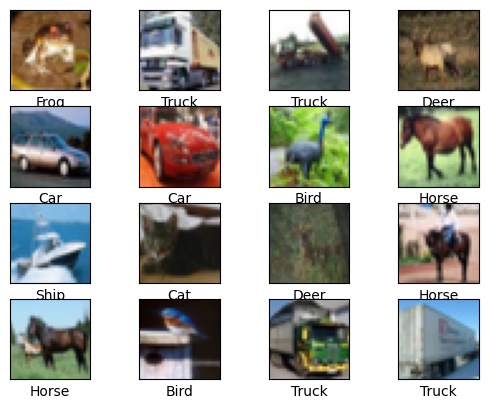

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.3499 - loss: 1.7501 - val_accuracy: 0.4498 - val_loss: 1.4983
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.5029 - loss: 1.3798 - val_accuracy: 0.5058 - val_loss: 1.3553
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.5519 - loss: 1.2437 - val_accuracy: 0.5530 - val_loss: 1.2310
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.5952 - loss: 1.1430 - val_accuracy: 0.5850 - val_loss: 1.1491
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.6240 - loss: 1.0563 - val_accuracy: 0.6025 - val_loss: 1.1264
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.6508 - loss: 0.9870 - val_accuracy: 0.6210 - val_loss: 1.0781
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.6712 - loss: 0.9269 - val_accuracy: 0.6230 - val_loss: 1.0624
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.6926 - loss: 0.8742 - 

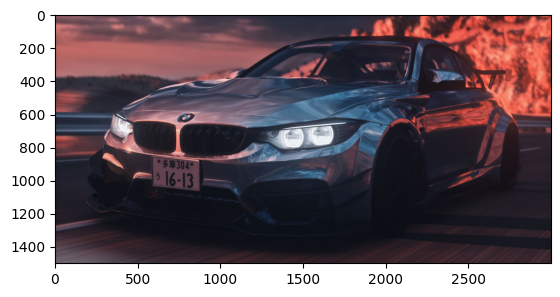

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets,layers,models

(training_images,training_labels),(testing_images,testing_labels)=datasets.cifar10.load_data()
training_images,testing_images=training_images/255,testing_images/255

class_names = ['Plane','Car','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(training_images[i],cmap=plt.cm.binary)
  plt.xlabel(class_names[training_labels[i][0]])

plt.show()

training_images = training_images[:20000]
training_labels = training_labels[:20000]
testing_images = testing_images[:4000]
testing_labels = testing_labels[:4000]

model = models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(training_images, training_labels, epochs=10, validation_data=(testing_images,testing_labels))

loss, accuracy = model.evaluate(testing_images,testing_labels)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

model.save('image_classifier.keras')

img = cv.imread('/content/car.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img,cmap=plt.cm.binary)


img = cv.resize(img,(32,32))
img = img.reshape(1,32,32,3)

prediction = model.predict(img/255)
index = np.argmax(prediction)
print(f'Prediction: {class_names[index]}')
